In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('loan_prediction.csv')
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [2]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [3]:
df = df.drop('Loan_ID', axis=1)

print("Columns after removing Loan_ID:")
print(df.columns.tolist())

Columns after removing Loan_ID:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [4]:
# Fill categorical missing values with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values with median
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                  'Loan_Amount_Term', 'Credit_History']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
# Convert categorical variables into numerical form
df = pd.get_dummies(
    df,
    columns=['Gender', 'Married', 'Dependents', 'Education',
             'Self_Employed', 'Property_Area'],
    drop_first=True
)

# Convert True/False values to 1/0
df = df.astype(int)

print("Dataset after encoding:")
print(df.head())
print("\nNew shape:", df.shape)

ValueError: invalid literal for int() with base 10: 'Y'

In [6]:
# Convert Loan_Status into numerical values
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

print("Dataset after encoding:")
print(df.head())

print("\nNew shape:", df.shape)

Dataset after encoding:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Loan_Status  Gender_Male  Married_Yes  Dependents_1  \
0             1.0            1         True        False         False   
1             1.0            0         True         True          True   
2             1.0            1         True         True         False   
3             1.0            1         True         True         False   
4             1.0            1         True        False         False   

   Dependents_2  Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0         False          Fa

In [7]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 14)
Target shape: (614,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 14)
Testing data: (123, 14)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Feature scaling completed.
Training data shape: (491, 14)
Testing data shape: (123, 14)


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model training completed.


In [11]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf[:20])

Random Forest predictions:
[0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1]


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation")
print("--------------------------------")
print("Accuracy:", round(accuracy_rf * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Model Evaluation
--------------------------------
Accuracy: 83.74 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.63      0.71        38
           1       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123

Confusion Matrix:
[[24 14]
 [ 6 79]]


In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


In [14]:
y_pred_lr = lr_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Model Evaluation")
print("------------------------------------")
print("Accuracy:", round(accuracy_lr * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Model Evaluation
------------------------------------
Accuracy: 86.18 %

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

Confusion Matrix:
[[22 16]
 [ 1 84]]


In [15]:
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_rf, accuracy_lr]
})

print(model_comparison)

                 Model  Accuracy
0        Random Forest  0.837398
1  Logistic Regression  0.861789


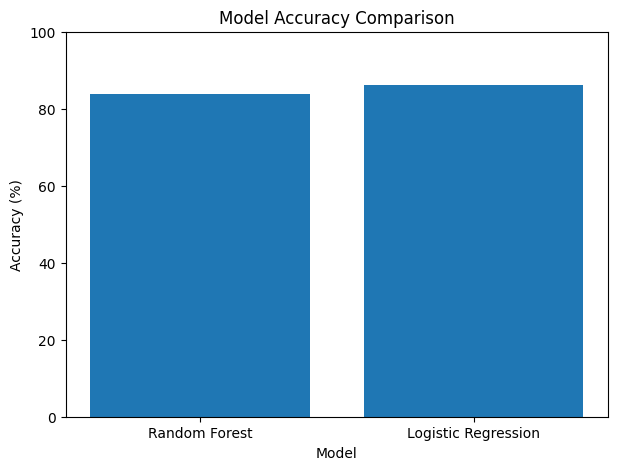

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(model_comparison['Model'], model_comparison['Accuracy'] * 100)

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)

plt.show()

In [17]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

svm_model.fit(X_train_scaled, y_train)

print("SVM model training completed.")


SVM model training completed.


In [18]:
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Model Evaluation")
print("--------------------")
print("Accuracy:", round(accuracy_svm * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Model Evaluation
--------------------
Accuracy: 85.37 %

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

Confusion Matrix:
[[21 17]
 [ 1 84]]


In [19]:
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM'],
    'Accuracy': [accuracy_rf, accuracy_lr, accuracy_svm]
})

model_comparison['Accuracy (%)'] = (
    model_comparison['Accuracy'] * 100
).round(2)

print(model_comparison[['Model', 'Accuracy (%)']])

                 Model  Accuracy (%)
0        Random Forest         83.74
1  Logistic Regression         86.18
2                  SVM         85.37


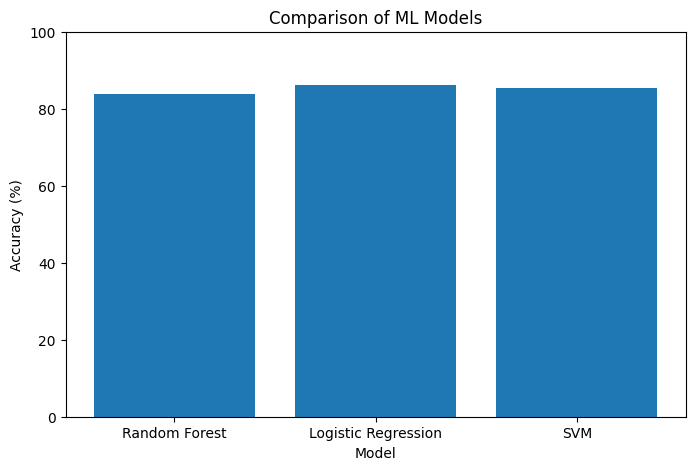

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy (%)']
)

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of ML Models')
plt.ylim(0, 100)

plt.show()

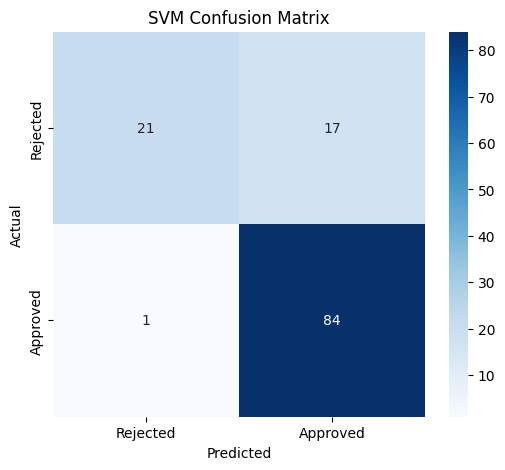

In [21]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')

plt.show()

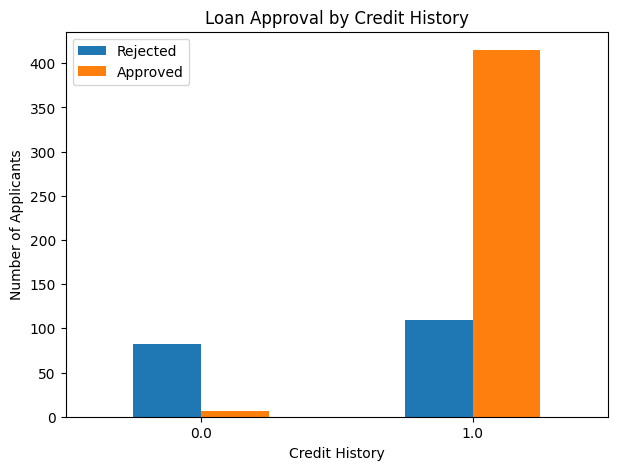

In [22]:
approval_by_credit = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
)

approval_by_credit.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.xlabel('Credit History')
plt.ylabel('Number of Applicants')
plt.title('Loan Approval by Credit History')
plt.xticks(rotation=0)
plt.legend(['Rejected', 'Approved'])

plt.show()

In [23]:
best_model = model_comparison.loc[
    model_comparison['Accuracy'].idxmax()
]

print("Best Performing Model:", best_model['Model'])
print("Best Accuracy:", round(best_model['Accuracy (%)'], 2), "%")

Best Performing Model: Logistic Regression
Best Accuracy: 86.18 %


In [24]:
# Sample applicant details
sample = X.iloc[[0]].copy()

# Select the best model
if best_model['Model'] == 'Random Forest':
    prediction = rf_model.predict(sample)[0]
elif best_model['Model'] == 'Logistic Regression':
    prediction = lr_model.predict(scaler.transform(sample))[0]
else:
    prediction = svm_model.predict(scaler.transform(sample))[0]

result = "Approved" if prediction == 1 else "Rejected"

print("Loan Approval Prediction")
print("------------------------")
print("Prediction:", result)

Loan Approval Prediction
------------------------
Prediction: Approved


In [25]:
print("RESULT INTERPRETATION")
print("--------------------")
print("Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")
print("Logistic Regression Accuracy:", round(accuracy_lr * 100, 2), "%")
print("SVM Accuracy:", round(accuracy_svm * 100, 2), "%")
print("Best Model:", best_model['Model'])
print("Best Accuracy:", round(best_model['Accuracy (%)'], 2), "%")
print("Final Prediction:", result)

RESULT INTERPRETATION
--------------------
Random Forest Accuracy: 83.74 %
Logistic Regression Accuracy: 86.18 %
SVM Accuracy: 85.37 %
Best Model: Logistic Regression
Best Accuracy: 86.18 %
Final Prediction: Approved


In [ ]:
df = df.drop('Loan_ID', axis=1)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
print(df.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [ ]:
# handling missing values

# Fill missing values in categorical columns with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Fill missing values in LoanAmount with the median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Fill missing values in Loan_Amount_Term with the mode
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# Fill missing values in Credit_History with the mode
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [ ]:
# exploratory data analysis(EDA)

import plotly.express as px

loan_status_count = df['Loan_Status'].value_counts()
fig_loan_status = px.pie(loan_status_count,
                         names=loan_status_count.index,
                         title='Loan Approval Status')
fig_loan_status.show()

In [ ]:
gender_count = df['Gender'].value_counts()
fig_gender = px.bar(gender_count,
                    x=gender_count.index,
                    y=gender_count.values,
                    title='Gender Distribution')
fig_gender.show()

In [ ]:
married_count = df['Married'].value_counts()
fig_married = px.bar(married_count,
                     x=married_count.index,
                     y=married_count.values,
                     title='Marital Status Distribution')
fig_married.show()

In [ ]:
education_count = df['Education'].value_counts()
fig_education = px.bar(education_count,
                       x=education_count.index,
                       y=education_count.values,
                       title='Education Distribution')
fig_education.show()

In [ ]:
self_employed_count = df['Self_Employed'].value_counts()
fig_self_employed = px.bar(self_employed_count,
                           x=self_employed_count.index,
                           y=self_employed_count.values,
                           title='Self-Employment Distribution')
fig_self_employed.show()

In [ ]:
fig_applicant_income = px.histogram(df, x='ApplicantIncome',
                                    title='Applicant Income Distribution')
fig_applicant_income.show()

In [ ]:
fig_income = px.box(df, x='Loan_Status',
                    y='ApplicantIncome',
                    color="Loan_Status",
                    title='Loan_Status vs ApplicantIncome')
fig_income.show()

In [ ]:
# Calculate the IQR
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['ApplicantIncome'] >= lower_bound) & (df['ApplicantIncome'] <= upper_bound)]

In [ ]:
fig_coapplicant_income = px.box(df,
                                x='Loan_Status',
                                y='CoapplicantIncome',
                                color="Loan_Status",
                                title='Loan_Status vs CoapplicantIncome')
fig_coapplicant_income.show()

In [ ]:
# Calculate the IQR
Q1 = df['CoapplicantIncome'].quantile(0.25)
Q3 = df['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['CoapplicantIncome'] >= lower_bound) & (df['CoapplicantIncome'] <= upper_bound)]

In [ ]:
fig_loan_amount = px.box(df, x='Loan_Status',
                         y='LoanAmount',
                         color="Loan_Status",
                         title='Loan_Status vs LoanAmount')
fig_loan_amount.show()

In [ ]:
fig_credit_history = px.histogram(df, x='Credit_History', color='Loan_Status',
                                  barmode='group',
                                  title='Loan_Status vs Credit_His')
fig_credit_history.show()

In [ ]:
fig_property_area = px.histogram(df, x='Property_Area', color='Loan_Status',
                                 barmode='group',
                                title='Loan_Status vs Property_Area')
fig_property_area.show()

In [ ]:
# Convert categorical columns to numerical using one-hot encoding
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=cat_cols)

# Split the dataset into features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numerical columns using StandardScaler
scaler = StandardScaler()
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

from sklearn.svm import SVC
model = SVC(random_state=42)
model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y'
 'Y' 'Y']


In [ ]:
# Convert X_test to a DataFrame
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Add the predicted values to X_test_df
X_test_df['Loan_Status_Predicted'] = y_pred
print(X_test_df.head())

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
277        -0.544528          -0.037922   -0.983772          0.305159   
84         -0.067325          -0.931554   -1.571353         -1.430680   
275        -0.734870           0.334654   -0.298262          0.305159   
392        -0.824919           0.522317   -0.200332          0.305159   
537        -0.267373          -0.931554   -0.454950          0.305159   

     Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  \
277        0.402248          False         True       False         True   
84         0.402248          False         True       False         True   
275        0.402248          False         True       False         True   
392        0.402248          False         True       False         True   
537        0.402248          False         True        True        False   

     Dependents_0  ...  Dependents_2  Dependents_3+  Education_Graduate  \
277          True  ...       

In [ ]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
confusion = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(confusion)

Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           N       0.94      0.49      0.64        35
           Y       0.80      0.99      0.89        75

    accuracy                           0.83       110
   macro avg       0.87      0.74      0.76       110
weighted avg       0.85      0.83      0.81       110

Confusion Matrix:
[[17 18]
 [ 1 74]]
